# Step 2: Make your autoencoder
Train a 64x16x64 autoencoder on the digits dataset

### Load the digits dataset

In [1]:
from sklearn.datasets import load_digits
digits = load_digits()

### Split the data into training and validation sets

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
# test
X = digits.data.astype(float) / digits.data.max()
y = X.copy() # autoencoder

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# train and val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# 20:20:60 split
print('training', X_train.shape)
print('validation', X_val.shape)
print('test', X_test.shape)

training (1077, 64)
validation (360, 64)
test (360, 64)


### Generate an instance of NN class with a 64x16x64 autoencoder architecture

In [4]:
from nn.nn import NeuralNetwork as nn

architecture = [{'input_dim': 64, 'output_dim': 16, 'activation': 'relu'},
               {'input_dim': 16, 'output_dim': 64, 'activation': 'relu'}]

Train

In [5]:
## tune hyperparams
from itertools import product

hp_grid = {
    "learning_rate": [0.0001, 0.001, 0.005],
    "batch_size": [50, 100, 300],
    "epochs": [100, 300, 500]}

hp_combos = list(product(*hp_grid.values()))

best_loss = float("inf")
best_params = None
results = []

In [6]:
for params in hp_combos:
    lr, batch_size, epochs = params

    nn_tune = nn(
        nn_arch= architecture,
        lr = lr,
        seed = 42,
        batch_size = batch_size,
        epochs = epochs,
        loss_function = "mean_squared_error")

    loss_train, loss_val = nn_tune.fit(X_train, X_train, X_val, X_val)

    final_loss = loss_val[-1]
    results.append((params, final_loss))

    if final_loss < best_loss:
        best_loss = final_loss
        best_params = params

print("Best Hyperparameters:", best_params)
print("Best Validation Loss:", best_loss)

Best Hyperparameters: (0.005, 100, 500)
Best Validation Loss: 0.031052557465569435


First run had 0.0001, 100, 1000. When trained, loss curves looked kind of bad LOL so I changed the hp grid to fine tune more... val loss 0.082

found 0.01, 300, 1000.. val loss 0.029 which also had a much nicer loss curve(s), but **lots** of noise. decided to decrease epochs and lr for fun

0.005, 100, 500 with val loss .031. Liked this loss curve the best when trained up with minimal increase of avg validation loss.

mse because output isn't binary

In [5]:
#train her up

autoencoder = nn(architecture, lr = 0.005, seed = 42, batch_size = 100, epochs = 500, loss_function = 'mean_squared_error')
train_losses, val_losses = autoencoder.fit(X_train, y_train, X_val, y_val)

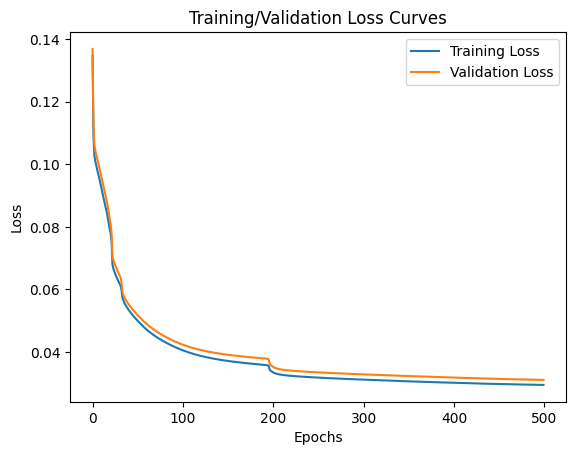

0.031052557465569435


In [6]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training/Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(val_losses[-1]) # average validation loss

Average Reconstruction Error

In [9]:
reconstructed = (autoencoder.predict(X_val.T)).T
print(f'avg reconstruction error: {np.mean(np.square(X_val - reconstructed))}')

avg reconstruction error: 0.031052557465569435


In [12]:
# uncertain of my own reconstruction and error lol
per_example = np.sum((reconstructed - X_val)**2, axis=1)
mse_per_example = np.mean(per_example)
mse_per_element = np.mean((reconstructed - X_val)**2)

print("mse_per_example:", mse_per_example)
print("mse_per_element:", mse_per_element)
print("D (output dim):", X_val.shape[1])
print("mse_per_example / D:", mse_per_example / X_val.shape[1])

mse_per_example: 1.9873636777964439
mse_per_element: 0.031052557465569435
D (output dim): 64
mse_per_example / D: 0.031052557465569435
